In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("loan_data.csv")
print(df.head())

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

In [5]:
df.duplicated().sum()
df.isna().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [6]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


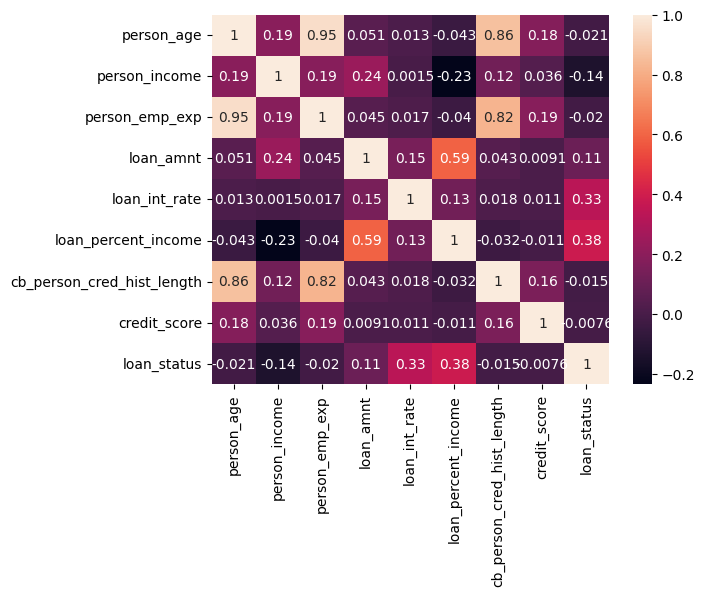

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [12]:
df.dtypes


,0
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_emp_exp,int64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64


In [16]:
df.nunique()

,0
person_age,60
person_gender,2
person_education,5
person_income,33989
person_emp_exp,63
person_home_ownership,4
loan_amnt,4483
loan_intent,6
loan_int_rate,1302
loan_percent_income,64


In [17]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(drop="first"),[1,2,5,7,12])],remainder="passthrough")
X = np.array(ct.fit_transform(X))
X[0]

array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0,
       0.0, 22.0, 71948.0, 0, 35000.0, 16.02, 0.49, 3.0, 561],
      dtype=object)

In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[:,14:] = scaler.fit_transform(X_train[:,14:])
X_test[:,14:] = scaler.transform(X_test[:,14:])
X_train


array([[1.0, 0.0, 0.0, ..., 0.11905357669720348, 0.8167316916770785,
        -0.032444025926228054],
       [0.0, 0.0, 0.0, ..., 0.23392087839905107, -0.47891373956994043,
        0.5246867770318279],
       [0.0, 0.0, 0.0, ..., -0.7998848369175763, 1.3349898641758862,
        1.00222746528159],
       ...,
       [0.0, 0.0, 0.0, ..., 0.46365548180274596, 0.8167316916770785,
        0.3854040762923139],
       [0.0, 0.0, 0.0, ..., -0.34041563011018644, -0.7380428258193442,
        -0.5696773002072105],
       [0.0, 0.0, 0.0, ..., -0.7998848369175763, -0.7380428258193442,
        0.624174420417195]], dtype=object)

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,confusion_matrix

# Random Forest Classifier

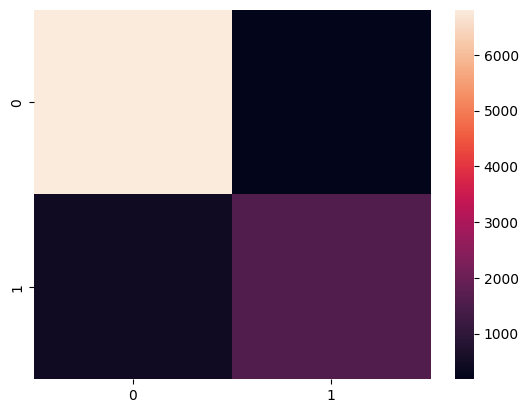

In [36]:
randomForestClassifier = RandomForestClassifier(n_estimators = 100,random_state = 42)
randomForestClassifier.fit(X_train,y_train)
y_pred = randomForestClassifier.predict(X_test)
sns.heatmap(confusion_matrix(y_test,y_pred))
plt.show()


In [37]:
accuracy_score(y_test,y_pred)


0.9292222222222222

# Support Vector Classifier

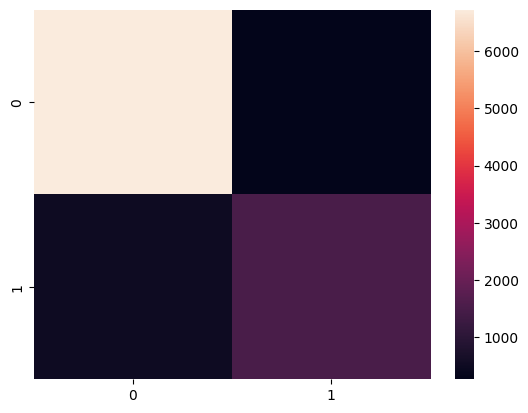

In [38]:
svClassifier = SVC(kernel = "rbf")
svClassifier.fit(X_train,y_train)
y_pred = svClassifier.predict(X_test)
sns.heatmap(confusion_matrix(y_test,y_pred))
plt.show()

In [39]:
accuracy_score(y_test,y_pred)

0.915

# KNN Classifier

In [32]:
knClassifier = KNeighborsClassifier()
knClassifier.fit(X_train,y_train)
y_pred = knClassifier.predict(X_test)

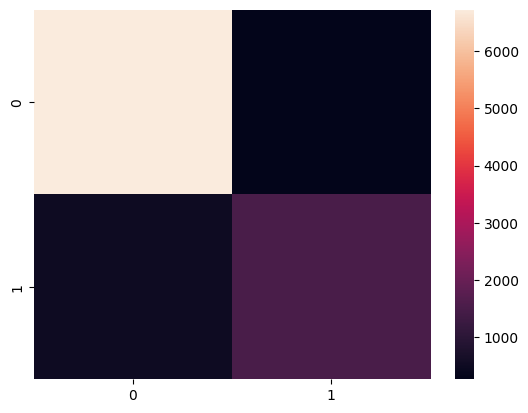

0.915

In [41]:
sns.heatmap(confusion_matrix(y_test,y_pred))
plt.show()
accuracy_score(y_test,y_pred)